# Reward-Verified Multi-Agent LLM Training and Testing

This notebook is the interactive entrypoint for the current paper framework:

- strict reward verification in the order `ground truth -> peer scores -> normalization -> trust -> attention -> final reward`
- trust-weighted, collusion-resistant peer aggregation
- optional revision rounds
- heuristic, Ollama, self-refine, and ICL backends
- train-style runs with `apply_updates=True`
- frozen test evaluation with `apply_updates=False`
- resumable outputs, manifests, summaries, and learning curves


## Contribution Framing

The core method in this codebase is:

**A reward-verified multi-agent pipeline where objective correctness is checked first, then peer judgments are normalized, trust-weighted, attention-weighted, and mixed with ground truth.**

Peer reward formula:
`R_peer_j = sum_i(a_ij * t_i * s_ij) / sum_i(a_ij * t_i)`

Final reward formula:
`R_j = alpha * R_gt_j + (1 - alpha) * R_peer_j`

The notebook below lets you run both training-style and testing-style experiments using the same code paths as the CLI and inspect `metadata.reward_verification` for each example.


In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Workspace: {ROOT}')

Workspace: c:\Users\mokku\OneDrive\Pictures\Multi-Agent-Reinforcement-Learning-main\Multi-Agent-Reinforcement-Learning-main


In [2]:
from IPython.display import HTML, display

display(HTML('''
<style>
:root {
  --bg: #f4efe7;
  --card: #fffaf4;
  --ink: #20303b;
  --muted: #667682;
  --accent: #c45d2f;
  --accent2: #176b5c;
  --line: #e3d8ca;
}
.hero {
  background: linear-gradient(135deg, #fff6ea 0%, #f3ebe0 60%, #ece4d8 100%);
  border: 1px solid var(--line);
  border-radius: 24px;
  padding: 24px 28px;
  box-shadow: 0 18px 40px rgba(44, 31, 21, 0.08);
  margin: 12px 0 24px 0;
}
.hero h1 {
  margin: 0 0 8px 0;
  font-size: 30px;
  color: var(--ink);
  letter-spacing: -0.03em;
}
.hero p {
  margin: 0;
  color: var(--muted);
  line-height: 1.55;
  font-size: 15px;
}
.chips {
  display: flex;
  gap: 10px;
  flex-wrap: wrap;
  margin-top: 14px;
}
.chip {
  padding: 7px 12px;
  border-radius: 999px;
  border: 1px solid rgba(23, 107, 92, 0.18);
  background: rgba(23, 107, 92, 0.08);
  color: var(--accent2);
  font-size: 12px;
  font-weight: 700;
}
</style>
<div class='hero'>
  <h1>MARL Paper Runner</h1>
  <p>Use this notebook to run train/test experiments for the trust-weighted multi-agent framework, inspect summaries, compare baselines, and export artifacts for analysis.</p>
  <div class='chips'>
    <span class='chip'>Trust-weighted scoring</span>
    <span class='chip'>Revision rounds</span>
    <span class='chip'>ICL memory</span>
    <span class='chip'>Self-refine baseline</span>
    <span class='chip'>Resumable runs</span>
  </div>
</div>
'''))

In [3]:
from environment import MultiAgentEnvironment
from experiment import ExperimentRunner, run_ablation_from_config
from run_demo import build_heuristic_agents, build_icl_ollama_agents, build_ollama_agents, DEFAULT_OLLAMA_MODELS
from agents import build_self_refine_ollama_agents
from run_experiment import chunk_tasks, iter_tasks

def build_agents(cfg):
    backend = cfg['backend']
    if backend == 'heuristic':
        return build_heuristic_agents()
    if backend == 'ollama':
        return build_ollama_agents(cfg['models'], cfg.get('ollama_host'), cfg['seed'])
    if backend == 'icl':
        return build_icl_ollama_agents(
            models=cfg['models'],
            host=cfg.get('ollama_host'),
            seed=cfg['seed'],
            memory_strategy=cfg.get('icl_strategy', 'reward_weighted'),
            prompt_memory_size=int(cfg.get('prompt_memory_size', 5)),
            memory_buffer_size=int(cfg.get('memory_buffer_size', 128)),
            oracle_gt_threshold=float(cfg.get('oracle_gt_threshold', 0.99)),
            include_eval_memory_in_prompt=bool(cfg.get('include_eval_memory_in_prompt', True)),
        )
    if backend == 'self_refine':
        return build_self_refine_ollama_agents(cfg['models'], cfg.get('ollama_host'), cfg['seed'])
    raise ValueError(f'Unknown backend: {backend}')

def run_pipeline(cfg):
    task_iter = iter_tasks(
        dataset_name=cfg['dataset'],
        split=cfg['split'],
        limit=cfg['limit'],
        seed=cfg['seed'],
        start_index=cfg['start_index'],
        streaming=cfg.get('streaming', False),
    )
    env = MultiAgentEnvironment(
        agents=build_agents(cfg),
        alpha=cfg['alpha'],
        task_type=cfg.get('task_type', 'flexible'),
        seed=cfg['seed'],
        max_concurrency=cfg.get('max_concurrency'),
        revision_rounds=cfg.get('revision_rounds', 0),
        continue_on_agent_error=cfg.get('continue_on_agent_error', True),
        use_trust_weighting=cfg.get('use_trust_weighting', True),
        historical_trust_blend=cfg.get('historical_trust_blend', 0.5),
        trust_floor=cfg.get('trust_floor', 0.1),
        use_attention=cfg.get('use_attention', True),
        attention_top_k=cfg.get('attention_top_k', 2),
        attention_temperature=cfg.get('attention_temperature', 1.0),
        attention_entropy_coef=cfg.get('attention_entropy_coef', 0.0),
    )
    runner = ExperimentRunner(env=env, output_dir=Path(cfg['output_dir']), run_manifest=cfg)
    result = None
    for batch in chunk_tasks(task_iter, cfg['batch_size']):
        result = runner.run(
            batch,
            resume=cfg.get('resume', False),
            apply_updates=cfg.get('apply_updates', False),
            track_learning_curve=cfg.get('track_learning_curve', True),
        )
    if result is None:
        result = runner.run([], resume=cfg.get('resume', False), apply_updates=cfg.get('apply_updates', False), track_learning_curve=cfg.get('track_learning_curve', True))
    return result

def inspect_reward_verification(record):
    verification = record['metadata']['reward_verification']
    return {
        'reward_formula': record['metadata'].get('reward_formula'),
        'stage_order': verification['stage_order'],
        'sanity_checks': verification['sanity_checks'],
        'ground_truth_reward': verification['ground_truth_reward'],
        'combined_peer_reward': verification['combined_peer_reward'],
        'final_reward': verification['final_reward'],
    }


## Training Configuration

This corresponds to the paper's train-style phase: updates are enabled, revision rounds can be enabled, ground-truth reward remains dominant through `alpha`, and trust plus attention are both configurable.


In [ ]:
TRAIN_CONFIG = {
    'dataset': 'gsm8k',
    'split': 'train',
    'backend': 'icl',
    'models': [
        'qwen3.5:latest',
        'deepseek-r1:7b',
        'gpt-oss:latest',
        'mistral:7b',
    ],
    'ollama_host': 'http://127.0.0.1:11434',
    'seed': 7,
    'limit': 50,
    'start_index': 0,
    'batch_size': 5,
    'alpha': 0.8,
    'task_type': 'flexible',
    'apply_updates': True,
    'resume': True,
    'track_learning_curve': True,
    'streaming': True,
    'max_concurrency': 4,
    'revision_rounds': 1,
    'continue_on_agent_error': True,
    'use_trust_weighting': True,
    'historical_trust_blend': 0.5,
    'trust_floor': 0.1,
    'use_attention': True,
    'attention_top_k': 2,
    'attention_temperature': 1.0,
    'attention_entropy_coef': 0.0,
    'icl_strategy': 'reward_weighted',
    'prompt_memory_size': 5,
    'memory_buffer_size': 128,
    'output_dir': 'outputs/notebook-train',
}

TRAIN_CONFIG


{'dataset': 'gsm8k',
 'split': 'train',
 'backend': 'icl',
 'models': ['qwen3.5:latest',
  'deepseek-r1:7b',
  'qwen2.5-coder:1.5b-base',
  'qwen2.5:3b-instruct'],
 'ollama_host': 'http://127.0.0.1:11434',
 'seed': 7,
 'limit': 50,
 'start_index': 0,
 'batch_size': 5,
 'alpha': 0.8,
 'task_type': 'flexible',
 'apply_updates': True,
 'resume': True,
 'track_learning_curve': True,
 'streaming': True,
 'max_concurrency': 4,
 'revision_rounds': 1,
 'continue_on_agent_error': True,
 'use_trust_weighting': True,
 'historical_trust_blend': 0.5,
 'trust_floor': 0.1,
 'use_attention': True,
 'attention_top_k': 2,
 'attention_temperature': 1.0,
 'attention_entropy_coef': 0.0,
 'icl_strategy': 'reward_weighted',
 'prompt_memory_size': 5,
 'memory_buffer_size': 128,
 'output_dir': 'outputs/notebook-train'}

In [5]:
# Run this cell to execute a train-style experiment.
train_result = run_pipeline(TRAIN_CONFIG)
train_result     

{'output_dir': 'outputs\\notebook-train',
 'results_path': 'outputs\\notebook-train\\results.jsonl',
 'summary_path': 'outputs\\notebook-train\\summary.json',
 'learning_curve_path': 'outputs\\notebook-train\\learning_curve.jsonl',
 'manifest_path': 'outputs\\notebook-train\\run_manifest.json',
 'new_examples_processed': 5,
 'total_examples': 50,
 'summary': {'num_examples': 50,
  'agent_metrics': {'qwen3.5:latest': {'mean_gt_reward': 0.8078,
    'mean_peer_score': 0.5396,
    'mean_final_reward': 0.7665,
    'gt_accuracy': 0.6,
    'mean_revision_gain': 0.4132,
    'mean_evaluator_alignment': 0.7105,
    'mean_trust_weight': 0.5708,
    'mean_attention_entropy': 1.0961,
    'mean_attention_bonus': 0.0,
    'mean_estimated_advantage': 0.7665,
    'pre_revision_accuracy': 0.2822,
    'post_revision_accuracy': 0.8079,
    'mean_step_progress_reward': -0.0474,
    'mean_belief_reward': 0.7982,
    'mean_failure_penalty': 0.0033,
    'mean_branch_bonus': 0.0,
    'mean_peer_recoverability_

## Testing Configuration

This corresponds to the paper's test phase: no updates, fixed configuration, test split.

In [6]:
TEST_CONFIG = {
    'dataset': 'gsm8k',
    'split': 'test',
    'backend': 'icl',
    'models': TRAIN_CONFIG['models'],
    'ollama_host': TRAIN_CONFIG['ollama_host'],
    'seed': 7,
    'limit': 25,
    'start_index': 0,
    'batch_size': 5,
    'alpha': 0.8,
    'task_type': 'flexible',
    'apply_updates': False,
    'resume': True,
    'track_learning_curve': True,
    'streaming': True,
    'max_concurrency': 4,
    'revision_rounds': 1,
    'continue_on_agent_error': True,
    'use_trust_weighting': True,
    'historical_trust_blend': 0.5,
    'trust_floor': 0.1,
    'use_attention': True,
    'attention_top_k': 2,
    'attention_temperature': 1.0,
    'attention_entropy_coef': 0.0,
    'icl_strategy': 'reward_weighted',
    'prompt_memory_size': 5,
    'memory_buffer_size': 128,
    'output_dir': 'outputs/notebook-test',
}

TEST_CONFIG


{'dataset': 'gsm8k',
 'split': 'test',
 'backend': 'icl',
 'models': ['qwen3.5:latest',
  'deepseek-r1:7b',
  'qwen2.5-coder:1.5b-base',
  'qwen2.5:3b-instruct'],
 'ollama_host': 'http://127.0.0.1:11434',
 'seed': 7,
 'limit': 25,
 'start_index': 0,
 'batch_size': 5,
 'alpha': 0.8,
 'task_type': 'flexible',
 'apply_updates': False,
 'resume': True,
 'track_learning_curve': True,
 'streaming': True,
 'max_concurrency': 4,
 'revision_rounds': 1,
 'continue_on_agent_error': True,
 'use_trust_weighting': True,
 'historical_trust_blend': 0.5,
 'trust_floor': 0.1,
 'use_attention': True,
 'attention_top_k': 2,
 'attention_temperature': 1.0,
 'attention_entropy_coef': 0.0,
 'icl_strategy': 'reward_weighted',
 'prompt_memory_size': 5,
 'memory_buffer_size': 128,
 'output_dir': 'outputs/notebook-test'}

In [7]:
# Run this cell t
# o execute a test-style evaluation.
test_result = run_pipeline(TEST_CONFIG)
test_result

{'output_dir': 'outputs\\notebook-test',
 'results_path': 'outputs\\notebook-test\\results.jsonl',
 'summary_path': 'outputs\\notebook-test\\summary.json',
 'learning_curve_path': 'outputs\\notebook-test\\learning_curve.jsonl',
 'manifest_path': 'outputs\\notebook-test\\run_manifest.json',
 'new_examples_processed': 5,
 'total_examples': 25,
 'summary': {'num_examples': 25,
  'agent_metrics': {'qwen3.5:latest': {'mean_gt_reward': 0.5694,
    'mean_peer_score': 0.4357,
    'mean_final_reward': 0.5475,
    'gt_accuracy': 0.28,
    'mean_revision_gain': 0.2123,
    'mean_evaluator_alignment': 0.6834,
    'mean_trust_weight': 0.4564,
    'mean_attention_entropy': 1.0973,
    'mean_attention_bonus': 0.0,
    'mean_estimated_advantage': 0.5475,
    'pre_revision_accuracy': 0.2828,
    'post_revision_accuracy': 0.5694,
    'mean_step_progress_reward': -0.132,
    'mean_belief_reward': 0.8143,
    'mean_failure_penalty': 0.0,
    'mean_branch_bonus': 0.0,
    'mean_peer_recoverability_reward':

## Baseline Switching

Useful backend choices for the paper:

- `heuristic`
- `ollama`
- `self_refine`
- `icl`

To compare baselines, duplicate `TEST_CONFIG`, change `backend`, `revision_rounds`, `use_trust_weighting`, and `use_attention`, then rerun.


In [8]:
SELF_REFINE_TEST = dict(TEST_CONFIG)
SELF_REFINE_TEST.update({
    'backend': 'self_refine',
    'apply_updates': False,
    'use_trust_weighting': False,
    'use_attention': False,
    'revision_rounds': 1,
    'output_dir': 'outputs/notebook-self-refine-test',
})

OLLAMA_NO_TRUST = dict(TEST_CONFIG)
OLLAMA_NO_TRUST.update({
    'backend': 'ollama',
    'apply_updates': False,
    'use_trust_weighting': False,
    'use_attention': False,
    'revision_rounds': 0,
    'output_dir': 'outputs/notebook-ollama-no-trust',
})

HEURISTIC_DEBUG = dict(TEST_CONFIG)
HEURISTIC_DEBUG.update({
    'dataset': 'gsm8k',
    'backend': 'heuristic',
    'apply_updates': False,
    'use_trust_weighting': True,
    'use_attention': True,
    'limit': 3,
    'output_dir': 'outputs/notebook-heuristic-debug',
})

SELF_REFINE_TEST, OLLAMA_NO_TRUST, HEURISTIC_DEBUG


({'dataset': 'gsm8k',
  'split': 'test',
  'backend': 'self_refine',
  'models': ['qwen3.5:latest',
   'deepseek-r1:7b',
   'qwen2.5-coder:1.5b-base',
   'qwen2.5:3b-instruct'],
  'ollama_host': 'http://127.0.0.1:11434',
  'seed': 7,
  'limit': 25,
  'start_index': 0,
  'batch_size': 5,
  'alpha': 0.8,
  'task_type': 'flexible',
  'apply_updates': False,
  'resume': True,
  'track_learning_curve': True,
  'streaming': True,
  'max_concurrency': 4,
  'revision_rounds': 1,
  'continue_on_agent_error': True,
  'use_trust_weighting': False,
  'historical_trust_blend': 0.5,
  'trust_floor': 0.1,
  'use_attention': False,
  'attention_top_k': 2,
  'attention_temperature': 1.0,
  'attention_entropy_coef': 0.0,
  'icl_strategy': 'reward_weighted',
  'prompt_memory_size': 5,
  'memory_buffer_size': 128,
  'output_dir': 'outputs/notebook-self-refine-test'},
 {'dataset': 'gsm8k',
  'split': 'test',
  'backend': 'ollama',
  'models': ['qwen3.5:latest',
   'deepseek-r1:7b',
   'qwen2.5-coder:1.5b-b

## Run YAML Ablations

This uses the exact paper ablation config from `configs/experiments.yaml`.

In [9]:
ABLATION_CONFIG = ROOT / 'configs' / 'experiments.yaml'
print(ABLATION_CONFIG)

# Uncomment to run the full ablation grid.
# ablation_summary = run_ablation_from_config(ABLATION_CONFIG)
# ablation_summary[:2]

c:\Users\mokku\OneDrive\Pictures\Multi-Agent-Reinforcement-Learning-main\Multi-Agent-Reinforcement-Learning-main\configs\experiments.yaml


## Load and Inspect Summary

In [10]:
def load_summary(output_dir):
    path = Path(output_dir) / 'summary.json'
    return json.loads(path.read_text(encoding='utf-8'))

summary = load_summary(TEST_CONFIG['output_dir'])
summary.keys()

dict_keys(['num_examples', 'agent_metrics', 'leaderboard', 'pairwise_win_matrix', 'verification_metrics'])

In [11]:
try:
    import pandas as pd
    display(pd.DataFrame(summary['leaderboard']))
    display(pd.DataFrame(summary['agent_metrics']).T)
except ImportError:
    print(json.dumps(summary, indent=2))

,agent,mean_final_reward,mean_gt_reward,gt_accuracy,win_rate,failure_rate,mean_trust_weight,mean_attention_entropy,post_revision_accuracy,mean_step_progress_reward,mean_belief_reward,mean_failure_penalty,mean_branch_bonus,mean_peer_recoverability_reward
0,qwen3.5:latest,0.5475,0.5694,0.28,0.20,0.24,0.4564,1.0973,0.5694,-0.132,0.8143,0.0,0.0,0.4357
1,deepseek-r1:7b,0.3871,0.3568,0.12,0.24,0.04,0.2206,1.0916,0.3568,-0.100,0.7887,0.0,0.0,0.4794
2,qwen2.5-coder:1.5b-base,0.3780,0.3568,0.20,0.32,0.04,0.2107,1.0880,0.3568,-0.134,0.7744,0.0,0.0,0.4855
3,qwen2.5:3b-instruct,0.3507,0.3616,0.20,0.24,0.00,0.4123,1.0897,0.3616,-0.244,0.7273,0.0,0.0,0.4883


,mean_gt_reward,mean_peer_score,mean_final_reward,gt_accuracy,mean_revision_gain,mean_evaluator_alignment,mean_trust_weight,mean_attention_entropy,mean_attention_bonus,mean_estimated_advantage,pre_revision_accuracy,post_revision_accuracy,mean_step_progress_reward,mean_belief_reward,mean_failure_penalty,mean_branch_bonus,mean_peer_recoverability_reward,win_rate,failure_rate
qwen3.5:latest,0.5694,0.4357,0.5475,0.28,0.2123,0.6834,0.4564,1.0973,0.0,0.5475,0.2828,0.5694,-0.132,0.8143,0.0,0.0,0.4357,0.20,0.24
deepseek-r1:7b,0.3568,0.4794,0.3871,0.12,0.2099,0.6381,0.2206,1.0916,0.0,0.3871,0.0963,0.3568,-0.100,0.7887,0.0,0.0,0.4794,0.24,0.04
qwen2.5-coder:1.5b-base,0.3568,0.4855,0.3780,0.20,0.1689,0.6573,0.2107,1.0880,0.0,0.3780,0.1757,0.3568,-0.134,0.7744,0.0,0.0,0.4855,0.32,0.04
qwen2.5:3b-instruct,0.3616,0.4883,0.3507,0.20,0.1727,0.6689,0.4123,1.0897,0.0,0.3507,0.1200,0.3616,-0.244,0.7273,0.0,0.0,0.4883,0.24,0.00


In [12]:
summary['pairwise_win_matrix']

{'qwen3.5:latest': {'deepseek-r1:7b': 13.0,
  'qwen2.5-coder:1.5b-base': 13.0,
  'qwen2.5:3b-instruct': 15.0},
 'deepseek-r1:7b': {'qwen3.5:latest': 11.0,
  'qwen2.5-coder:1.5b-base': 12.0,
  'qwen2.5:3b-instruct': 15.0},
 'qwen2.5-coder:1.5b-base': {'qwen3.5:latest': 12.0,
  'deepseek-r1:7b': 12.0,
  'qwen2.5:3b-instruct': 17.0},
 'qwen2.5:3b-instruct': {'qwen3.5:latest': 10.0,
  'deepseek-r1:7b': 10.0,
  'qwen2.5-coder:1.5b-base': 8.0}}

## Inspect Raw Results and Failures

In [13]:
results_path = Path(TEST_CONFIG['output_dir']) / 'results.jsonl'
rows = [json.loads(line) for line in results_path.read_text(encoding='utf-8').splitlines() if line.strip()]
print('num rows:', len(rows))
rows[0]['metadata'].keys() if rows else None

num rows: 25


dict_keys(['ground_truth', 'task_type', 'task_id', 'alpha', 'gt_has_variance', 'aggregation_method', 'reward_formula', 'use_rl', 'use_attention', 'revision_rounds', 'agent_failures', 'reward_verification', 'reward_breakdown', 'pre_revision_accuracy', 'post_revision_accuracy', 'initial_round', 'revision_history', 'peer_evaluations', 'attention_weights'])

In [14]:
if rows:
    rows[0]['metadata']['agent_failures']


## Inspect Reward Verification

Use this section to inspect the strict reward pipeline on a saved example, including stage order, formula, sanity checks, and the per-stage tables.


In [15]:
if rows:
    verification = rows[0]['metadata']['reward_verification']
    print(rows[0]['metadata'].get('reward_formula'))
    print('stage order:', verification['stage_order'])
    print('sanity checks:', verification['sanity_checks'])
    try:
        import pandas as pd
        display(pd.DataFrame(verification['ground_truth_reward']))
        display(pd.DataFrame(verification['score_normalization']))
        display(pd.DataFrame(verification['trust_weighting']['evaluators']))
        display(pd.DataFrame(verification['combined_peer_reward']))
        display(pd.DataFrame(verification['final_reward']))
    except ImportError:
        print(json.dumps(inspect_reward_verification(rows[0]), indent=2))
else:
    print('No result rows found yet.')


R = alpha*R_final + beta*sum(delta_u) + gamma*mean(b_t) - delta*mean(f_t) + eta*peer_salvageability + zeta*branch_bonus; peer_salvageability = sum_i(a_ij*t_i*s_ij)/sum_i(a_ij*t_i) with s_ij = salvageability scores
stage order: ['ground_truth_reward', 'raw_peer_salvageability_scores', 'score_normalization', 'trust_weighting', 'attention_weighting', 'combined_peer_recoverability', 'recoverability_components', 'final_recoverability_reward', 'sanity_checks']
sanity checks: {'self_evaluation_blocked': True, 'normalization_preserves_ranking': True, 'attention_probabilities_valid': True, 'peer_scores_bounded': True, 'final_rewards_bounded': True, 'uniform_trust_attention_reduce_to_mean': None}


,agent,answer,reward,is_correct
0,qwen3.5:latest,$18,0.9000,False
1,deepseek-r1:7b,$ 18,0.8333,False
2,qwen2.5-coder:1.5b-base,12,0.2500,False
3,qwen2.5:3b-instruct,18,1.0000,True


,evaluator,raw_scores,normalized_scores,preserves_ranking,flat_penalty_applied
0,qwen3.5:latest,"[None, 1.0, 0.0, 1.0]","[None, 1.0, 0.0, 1.0]",True,False
1,deepseek-r1:7b,"[0.0, None, 0.0, 0.0]","[0.5, None, 0.5, 0.5]",True,True
2,qwen2.5-coder:1.5b-base,"[0.0, 0.0, None, 0.0]","[0.5, 0.5, None, 0.5]",True,True
3,qwen2.5:3b-instruct,"[0.5, 0.5, 1.0, None]","[0.0, 0.0, 1.0, None]",True,False


,evaluator,historical_trust,anti_collusion_weight,disagreement_penalty,trust_weight
0,qwen3.5:latest,0.5,0.9167,0.0833,0.6875
1,deepseek-r1:7b,0.5,0.2695,0.2300,0.2021
2,qwen2.5-coder:1.5b-base,0.5,0.2637,0.2467,0.1977
3,qwen2.5:3b-instruct,0.5,0.5033,0.4967,0.3775


KeyError: 'combined_peer_reward'

## Plot Learning Curves

In [ ]:
from analysis.plot_learning_curves import load_rows, plot_mean_gt_reward

lc_path = Path(TEST_CONFIG['output_dir']) / 'learning_curve.jsonl'
if lc_path.exists():
    lc_rows = load_rows(lc_path)
    plot_mean_gt_reward(lc_rows, window=3)
else:
    print('No learning curve file found yet.')

## Notes for the Paper

Recommended primary comparisons:

- `ollama_baseline`: no trust weighting, no revision
- `self_refine_baseline`: no peer-informed revision
- `ollama_revision`: peer-informed revision without memory
- `icl_reward_weighted_no_trust`: memory without trust weighting
- `icl_reward_weighted`: trust-weighted memory-based system
- `icl_reward_weighted_revision`: full method

Recommended headline metrics:

- `gt_accuracy`
- `mean_final_reward`
- `win_rate`
- `mean_revision_gain`
- `mean_evaluator_alignment`
- `mean_trust_weight`
- `failure_rate`

Recommended verification artifacts to inspect alongside metrics:

- `metadata.reward_verification.stage_order`
- `metadata.reward_verification.score_normalization`
- `metadata.reward_verification.trust_weighting`
- `metadata.reward_verification.attention_weighting`
- `metadata.reward_verification.sanity_checks`


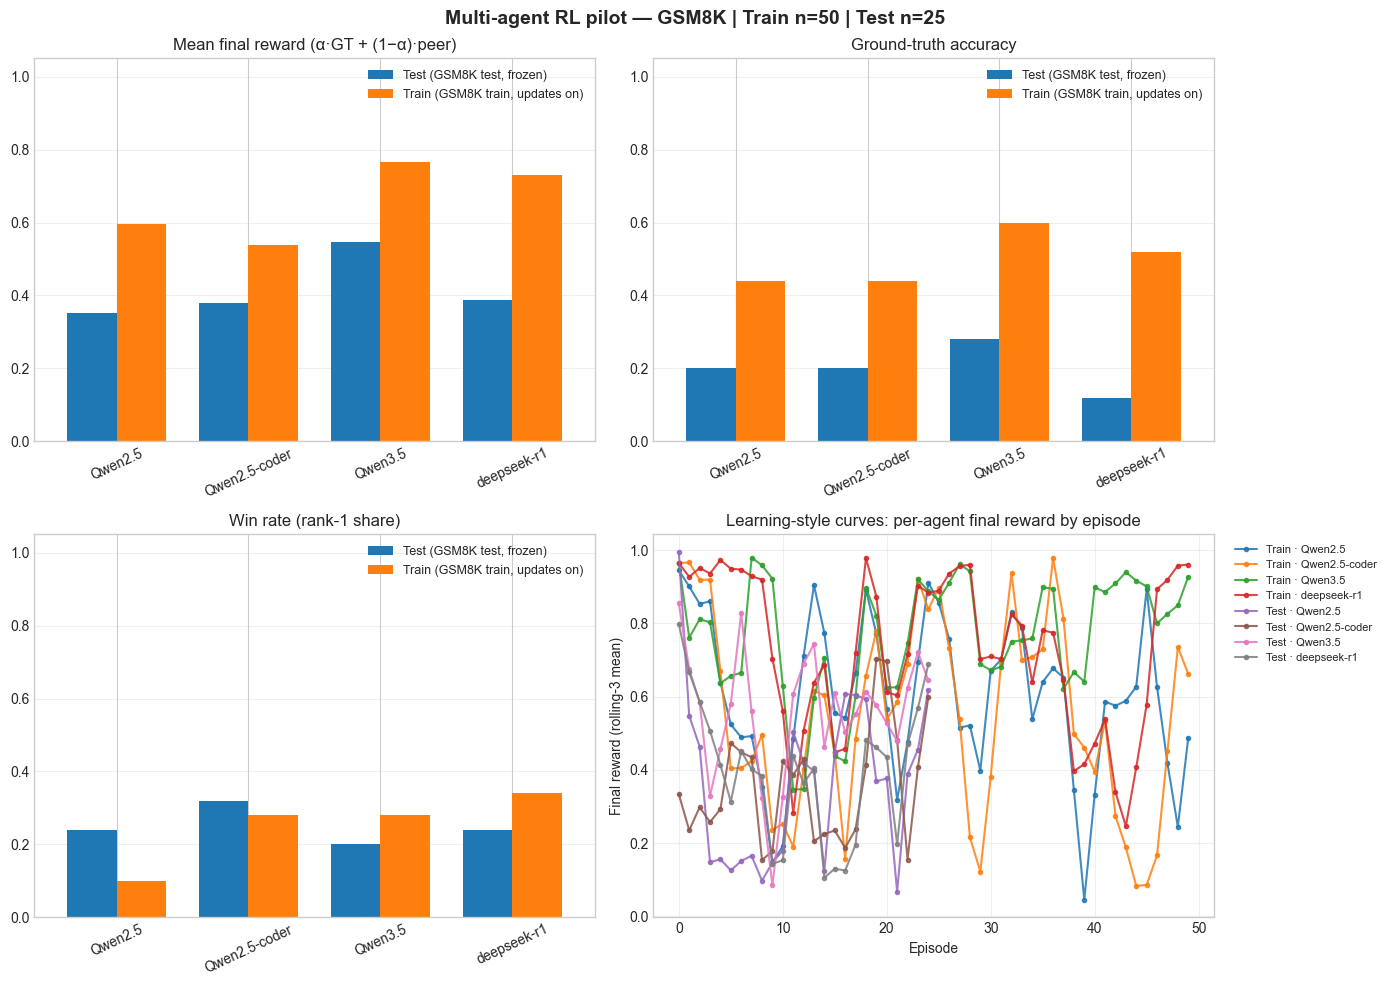

Saved: c:\Users\mokku\OneDrive\Pictures\Multi-Agent-Reinforcement-Learning-main\Multi-Agent-Reinforcement-Learning-main\outputs\stakeholder_pilot_dashboard.png

--- Key metrics (copy for slides) ---
                          phase         agent  mean_final_reward  gt_accuracy  win_rate  failure_rate
Train (GSM8K train, updates on)       Qwen3.5             0.7665       0.6000    0.2800        0.3400
Train (GSM8K train, updates on)   deepseek-r1             0.7305       0.5200    0.3400        0.0800
Train (GSM8K train, updates on) Qwen2.5-coder             0.5383       0.4400    0.2800        0.0200
Train (GSM8K train, updates on)       Qwen2.5             0.5952       0.4400    0.1000        0.0200
      Test (GSM8K test, frozen)       Qwen3.5             0.5475       0.2800    0.2000        0.2400
      Test (GSM8K test, frozen)   deepseek-r1             0.3871       0.1200    0.2400        0.0400
      Test (GSM8K test, frozen) Qwen2.5-coder             0.3780       0.2000    0.3200

In [16]:
"""
Stakeholder-friendly plots for outputs/notebook-train and outputs/notebook-test.
Run from the project root:  python visualize_stakeholder_runs.py
Or paste into a notebook and set ROOT to Path.cwd().
"""
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- paths (edit if needed) ---
ROOT = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
RUNS = {
    "Train (GSM8K train, updates on)": ROOT / "outputs" / "notebook-train",
    "Test (GSM8K test, frozen)": ROOT / "outputs" / "notebook-test",
}


def short_agent(name: str) -> str:
    """Short labels for chart axes."""
    return name.split(":")[0].replace("qwen", "Qwen")


def load_summary(run_dir: Path) -> dict:
    with (run_dir / "summary.json").open(encoding="utf-8") as f:
        return json.load(f)


def load_learning_curve(run_dir: Path) -> list[dict]:
    path = run_dir / "learning_curve.jsonl"
    if not path.exists():
        return []
    rows = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def summaries_to_dataframe(label: str, summary: dict) -> pd.DataFrame:
    rows = []
    for agent, m in summary["agent_metrics"].items():
        rows.append(
            {
                "phase": label,
                "agent": short_agent(agent),
                "full_name": agent,
                "n_examples": summary.get("num_examples"),
                **m,
            }
        )
    return pd.DataFrame(rows)


def plot_comparison_bar(df: pd.DataFrame, metric: str, title: str, ax: plt.Axes) -> None:
    pivot = df.pivot(index="agent", columns="phase", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=25, width=0.75)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="", fontsize=9, loc="best")
    ax.grid(axis="y", alpha=0.3)


def learning_curve_to_frame(rows: list[dict]) -> pd.DataFrame:
    """One row per episode per agent: episode_index, agent, final_reward, won."""
    out = []
    for row in rows:
        ep = row["episode_index"]
        for agent, stats in row.get("per_agent", {}).items():
            out.append(
                {
                    "episode_index": ep,
                    "agent": short_agent(agent),
                    "full_name": agent,
                    "final_reward": stats["final_reward"],
                    "won": stats.get("won", False),
                }
            )
    return pd.DataFrame(out)


def plot_learning_curves(
    train_lc: pd.DataFrame,
    test_lc: pd.DataFrame,
    ax: plt.Axes,
    rolling: int = 3,
) -> None:
    """Rolling mean of final reward vs episode (per agent)."""
    for label, lc_df in [("Train", train_lc), ("Test", test_lc)]:
        if lc_df.empty:
            continue
        for agent in sorted(lc_df["agent"].unique()):
            sub = lc_df[lc_df["agent"] == agent].sort_values("episode_index")
            y = sub["final_reward"].values
            x = sub["episode_index"].values
            if rolling > 1 and len(y) >= rolling:
                y = pd.Series(y).rolling(rolling, min_periods=1).mean().values
            ax.plot(x, y, marker="o", ms=3, alpha=0.85, label=f"{label} · {agent}")
    ax.set_xlabel("Episode")
    ax.set_ylabel(f"Final reward (rolling-{rolling} mean)")
    ax.set_title("Learning-style curves: per-agent final reward by episode")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


def main() -> None:
    plt.style.use("seaborn-v0_8-whitegrid")
    fig = plt.figure(figsize=(14, 10))

    summaries = {label: load_summary(d) for label, d in RUNS.items()}
    dfs = [summaries_to_dataframe(label, s) for label, s in summaries.items()]
    df = pd.concat(dfs, ignore_index=True)

    # Text slide: scale
    n_train = summaries[list(RUNS.keys())[0]].get("num_examples", "?")
    n_test = summaries[list(RUNS.keys())[1]].get("num_examples", "?")
    fig.suptitle(
        f"Multi-agent RL pilot — GSM8K | Train n={n_train} | Test n={n_test}",
        fontsize=14,
        fontweight="bold",
    )

    ax1 = fig.add_subplot(2, 2, 1)
    plot_comparison_bar(df, "mean_final_reward", "Mean final reward (α·GT + (1−α)·peer)", ax1)
    ax1.set_ylim(0, 1.05)

    ax2 = fig.add_subplot(2, 2, 2)
    plot_comparison_bar(df, "gt_accuracy", "Ground-truth accuracy", ax2)
    ax2.set_ylim(0, 1.05)

    ax3 = fig.add_subplot(2, 2, 3)
    plot_comparison_bar(df, "win_rate", "Win rate (rank-1 share)", ax3)
    ax3.set_ylim(0, 1.05)

    ax4 = fig.add_subplot(2, 2, 4)
    train_rows = load_learning_curve(RUNS[list(RUNS.keys())[0]])
    test_rows = load_learning_curve(RUNS[list(RUNS.keys())[1]])
    train_lc = learning_curve_to_frame(train_rows)
    test_lc = learning_curve_to_frame(test_rows)
    plot_learning_curves(train_lc, test_lc, ax4, rolling=3)

    plt.tight_layout()
    out = ROOT / "outputs" / "stakeholder_pilot_dashboard.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

    # Optional: compact table for slides
    print("\n--- Key metrics (copy for slides) ---")
    cols = ["phase", "agent", "mean_final_reward", "gt_accuracy", "win_rate", "failure_rate"]
    print(df[cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))


if __name__ == "__main__":
    main()